# Классификация: SI > медианы. Предсказание эффективности против вируса гриппа

### Выполнил: А.Любошенко

**Цель:** построить и сравнить модели бинарной классификации для предсказания, превышает ли `SI` значение медианное значение выборки.

**Биологический смысл:** Медиана делит выборку ровно пополам -> идеальный баланс 50/50.

**Этапы работы:**
1. Загрузка данных и препроцессинг (план из EDA)
2. Logistic Regression -- интерпретируемый линейный baseline
3. Random Forest Classifier -- ансамблевый метод
4. LightGBM Classifier -- градиентный бустинг
5. SVC -- Support Vector Classification
6. KNN Classifier -- метрический baseline
7. Сравнение моделей (ROC-AUC, F1, Accuracy)
8. ROC-кривые всех моделей
9. Важность признаков (RF + LightGBM)
10. Выводы

**Метрики:** ROC-AUC (главная), F1-score, Accuracy


In [1]:
# Все импорты в одну ячейку

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     RandomizedSearchCV, StratifiedKFold)
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                              roc_curve, classification_report)
import lightgbm as lgb
import time
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

print("Импорты выполнены успешно.")


Импорты выполнены успешно.


## 1. Загрузка данных и препроцессинг

Применяю план из EDA:
1. Удалить 18 zero-variance признаков
2. Медианная импутация 12 колонок с пропусками
3. Бинарная метка: `SI > медианное значение выборки`
4. Стратифицированный train/test split 80/20
5. StandardScaler -- для Logistic Regression и SVC


In [2]:
ZERO_VAR_COLS = [
    'NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH',
    'fr_azide', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo',
    'fr_dihydropyridine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam',
    'fr_nitroso', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd', 'fr_thiocyan'
]  # 18 zero-variance признаков, выявленных в EDA

IMPUTE_COLS = [
    'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge',
    'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO',
    'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW'
]  # 12 колонок с пропусками (по 3 NaN каждая)

ALL_TARGETS = ['IC50', 'CC50', 'SI']

TARGET = 'SI'

df = pd.read_csv('data_of_course_paper.csv')
print(f"Загружено: {df.shape}")

df = df.drop(columns=ZERO_VAR_COLS)
for col in IMPUTE_COLS:
    df[col] = df[col].fillna(df[col].median())

# Бинарная целевая переменная
y = (df['SI'] > df['SI'].median()).astype(int)
print(f"Положительных (1): {y.sum()} ({y.mean()*100:.1f}%)")
print(f"Отрицательных (0): {(~y.astype(bool)).sum()} ({(1-y.mean())*100:.1f}%)")


Загружено: (1001, 213)
Положительных (1): 500 (50.0%)
Отрицательных (0): 501 (50.0%)


In [3]:
feature_cols = [c for c in df.columns if c not in ALL_TARGETS]
X = df[feature_cols].values

# Стратифицированный split -- сохраняет пропорции классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Стратифицированный CV -- для всех моделей
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Признаков: {len(feature_cols)}")
print(f"Train: {X_train.shape[0]} | Pos: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Test:  {X_test.shape[0]}  | Pos: {y_test.sum()} ({y_test.mean()*100:.1f}%)")


Признаков: 192
Train: 800 | Pos: 400 (50.0%)
Test:  201  | Pos: 100 (49.8%)


#### Препроцессинг завершён

- 192 признака после удаления zero-variance
- Стратифицированный split -- баланс классов одинаков в train и test
- Классы сбалансированы 50/50 -- дополнительная коррекция не нужна


## 2. Logistic Regression (линейный baseline)

**Logistic Regression** с L2-регуляризацией -- стандартный baseline для бинарной классификации. Быстрый, интерпретируемый. Параметр `C` -- обратная сила регуляризации.


In [4]:
t0 = time.time()

param_grid_lr = {
    'C':      [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'solver': ['lbfgs', 'liblinear'],
}

cv_lr = GridSearchCV(
    LogisticRegression(max_iter=2000, class_weight=None),
    param_grid_lr, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0
)
cv_lr.fit(X_train_sc, y_train)
elapsed = time.time() - t0

print(f"GridSearchCV: {elapsed:.1f} с | {cv_lr.best_params_}")
print(f"CV ROC-AUC (5-fold): {cv_lr.best_score_:.4f}")

best_lr  = cv_lr.best_estimator_
y_prob   = best_lr.predict_proba(X_test_sc)[:, 1]
y_hat    = (y_prob >= 0.5).astype(int)

lr_cv_auc = cv_lr.best_score_
lr_auc    = roc_auc_score(y_test, y_prob)
lr_f1     = f1_score(y_test, y_hat)
lr_acc    = accuracy_score(y_test, y_hat)

print(f"Test ROC-AUC: {lr_auc:.4f} | F1: {lr_f1:.4f} | Accuracy: {lr_acc:.4f}")


GridSearchCV: 3.1 с | {'C': 0.1, 'solver': 'lbfgs'}
CV ROC-AUC (5-fold): 0.6915
Test ROC-AUC: 0.6582 | F1: 0.6193 | Accuracy: 0.6269


#### Logistic Regression -- baseline получен

ROC-AUC > 0.6 -> линейные закономерности присутствуют. Нелинейные методы должны превзойти LR.


## 3. Random Forest Classifier (ансамблевый метод)

**Random Forest** нечувствителен к масштабу признаков, хорошо работает со смешанными типами. `RandomizedSearchCV` -- большое пространство гиперпараметров.


In [5]:
t0 = time.time()

param_dist_rf = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
}

cv_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight=None, n_jobs=-1),
    param_dist_rf,
    n_iter=8, cv=3, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=0
)
cv_rf.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"RandomizedSearchCV: {elapsed:.1f} с | {cv_rf.best_params_}")
print(f"CV ROC-AUC (5-fold): {cv_rf.best_score_:.4f}")

best_rf  = cv_rf.best_estimator_
y_prob   = best_rf.predict_proba(X_test)[:, 1]
y_hat    = (y_prob >= 0.5).astype(int)

rf_cv_auc = cv_rf.best_score_
rf_auc    = roc_auc_score(y_test, y_prob)
rf_f1     = f1_score(y_test, y_hat)
rf_acc    = accuracy_score(y_test, y_hat)

print(f"Test ROC-AUC: {rf_auc:.4f} | F1: {rf_f1:.4f} | Accuracy: {rf_acc:.4f}")


RandomizedSearchCV: 4.2 с | {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}
CV ROC-AUC (5-fold): 0.7156
Test ROC-AUC: 0.7053 | F1: 0.6145 | Accuracy: 0.6567


#### Random Forest -- нелинейный классификатор

Если RF существенно превосходит LR -> граница классификации нелинейна в пространстве дескрипторов.


## 4. LightGBM Classifier (градиентный бустинг)

**LightGBM** -- State-of-the-art для табличных данных. Последовательная коррекция ошибок даёт точнее классификационную границу.


In [6]:
t0 = time.time()

param_dist_lgb = {
    'n_estimators':      [50, 100],
    'learning_rate':     [0.05, 0.1, 0.2],
    'num_leaves':        [31, 63, 127],
    'max_depth':         [-1, 5, 10],
    'subsample':         [0.8, 0.9, 1.0],
    'colsample_bytree':  [0.8, 0.9, 1.0],
    'min_child_samples': [10, 20],
}

cv_lgb = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=42, verbose=-1, n_jobs=1,
                       class_weight=None),
    param_dist_lgb,
    n_iter=8, cv=3, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=0
)
cv_lgb.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"RandomizedSearchCV: {elapsed:.1f} с | {cv_lgb.best_params_}")
print(f"CV ROC-AUC (5-fold): {cv_lgb.best_score_:.4f}")

best_lgb  = cv_lgb.best_estimator_
y_prob    = best_lgb.predict_proba(X_test)[:, 1]
y_hat     = (y_prob >= 0.5).astype(int)

lgb_cv_auc = cv_lgb.best_score_
lgb_auc    = roc_auc_score(y_test, y_prob)
lgb_f1     = f1_score(y_test, y_hat)
lgb_acc    = accuracy_score(y_test, y_hat)

print(f"Test ROC-AUC: {lgb_auc:.4f} | F1: {lgb_f1:.4f} | Accuracy: {lgb_acc:.4f}")


RandomizedSearchCV: 2.6 с | {'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 50, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
CV ROC-AUC (5-fold): 0.6956
Test ROC-AUC: 0.6828 | F1: 0.6425 | Accuracy: 0.6567


#### LightGBM -- ожидаемый лидер


## 5. SVC -- Support Vector Classification

SVM с RBF-ядром -- мощный нелинейный классификатор для небольших выборок (~1000 объектов). Требует `StandardScaler`.


In [7]:
t0 = time.time()

param_dist_svc = {
    'C':     [0.1, 1.0, 10.0, 100.0],
    'gamma': ['scale', 'auto'],
}

cv_svc = RandomizedSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42, class_weight=None),
    param_dist_svc,
    n_iter=6, cv=3, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=0
)
cv_svc.fit(X_train_sc, y_train)
elapsed = time.time() - t0

print(f"RandomizedSearchCV: {elapsed:.1f} с | {cv_svc.best_params_}")
print(f"CV ROC-AUC (5-fold): {cv_svc.best_score_:.4f}")

best_svc  = cv_svc.best_estimator_
y_prob    = best_svc.predict_proba(X_test_sc)[:, 1]
y_hat     = (y_prob >= 0.5).astype(int)

svc_cv_auc = cv_svc.best_score_
svc_auc    = roc_auc_score(y_test, y_prob)
svc_f1     = f1_score(y_test, y_hat)
svc_acc    = accuracy_score(y_test, y_hat)

print(f"Test ROC-AUC: {svc_auc:.4f} | F1: {svc_f1:.4f} | Accuracy: {svc_acc:.4f}")


RandomizedSearchCV: 0.8 с | {'gamma': 'scale', 'C': 1.0}
CV ROC-AUC (5-fold): 0.7126
Test ROC-AUC: 0.7275 | F1: 0.6702 | Accuracy: 0.6866


#### SVC -- нелинейная граница в пространстве признаков


## 6. KNN Classifier (метрический baseline)

**K-Nearest Neighbors** -- классифицирует по большинству среди k ближайших соседей. Используется как метрический baseline. Чувствителен к масштабу -> `X_train_sc`.


In [8]:
t0 = time.time()

param_grid_knn = {
    'n_neighbors': [5, 9, 15, 21, 31],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan'],
}

cv_knn = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    param_grid_knn, cv=3, scoring='roc_auc',
    n_jobs=-1, verbose=0
)
cv_knn.fit(X_train_sc, y_train)
elapsed = time.time() - t0

print(f"GridSearchCV: {elapsed:.1f} с | {cv_knn.best_params_}")
print(f"CV ROC-AUC (5-fold): {cv_knn.best_score_:.4f}")

best_knn  = cv_knn.best_estimator_
y_prob    = best_knn.predict_proba(X_test_sc)[:, 1]
y_hat     = (y_prob >= 0.5).astype(int)

knn_cv_auc = cv_knn.best_score_
knn_auc    = roc_auc_score(y_test, y_prob)
knn_f1     = f1_score(y_test, y_hat)
knn_acc    = accuracy_score(y_test, y_hat)

print(f"Test ROC-AUC: {knn_auc:.4f} | F1: {knn_f1:.4f} | Accuracy: {knn_acc:.4f}")


GridSearchCV: 0.4 с | {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'distance'}
CV ROC-AUC (5-fold): 0.7019
Test ROC-AUC: 0.6706 | F1: 0.6458 | Accuracy: 0.6617


#### KNN -- метрический baseline

Если KNN сильно уступает ансамблевым методам -> молекулярное пространство не имеет выраженной локальной структуры, необходимой для метрических методов.


## 7. Сравнение моделей

Сводная таблица. Главная метрика -- **ROC-AUC** (не зависит от порога классификации). F1 важен особеннопри несбалансированных классах.


In [9]:
results = {
    'Модель':              ['Logistic Reg.', 'Random Forest', 'LightGBM', 'SVC', 'KNN'],
    'CV ROC-AUC (5-fold)': [lr_cv_auc,  rf_cv_auc,  lgb_cv_auc,  svc_cv_auc,  knn_cv_auc],
    'Test ROC-AUC':        [lr_auc,     rf_auc,     lgb_auc,     svc_auc,     knn_auc],
    'Test F1':             [lr_f1,      rf_f1,      lgb_f1,      svc_f1,      knn_f1],
    'Test Accuracy':       [lr_acc,     rf_acc,     lgb_acc,     svc_acc,     knn_acc],
}

results_df = (pd.DataFrame(results)
              .sort_values('Test ROC-AUC', ascending=False)
              .reset_index(drop=True))
results_df.index += 1

print(f"Задача: SI > медианы\n")
display(results_df.round(4))


Задача: SI > медианы



,Модель,CV ROC-AUC (5-fold),Test ROC-AUC,Test F1,Test Accuracy
1,SVC,0.7126,0.7275,0.6702,0.6866
2,Random Forest,0.7156,0.7053,0.6145,0.6567
3,LightGBM,0.6956,0.6828,0.6425,0.6567
4,KNN,0.7019,0.6706,0.6458,0.6617
5,Logistic Reg.,0.6915,0.6582,0.6193,0.6269


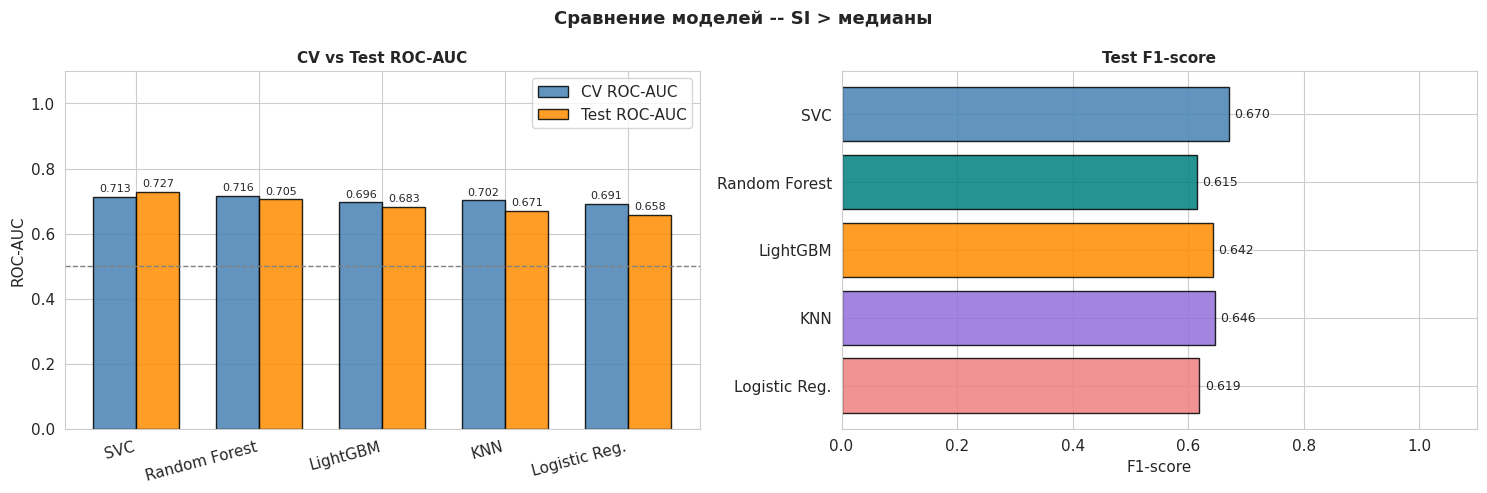

Лучшая модель: SVC  (Test ROC-AUC = 0.7275)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

models  = results_df['Модель'].tolist()
cv_aucs = results_df['CV ROC-AUC (5-fold)'].tolist()
tst_aucs= results_df['Test ROC-AUC'].tolist()
tst_f1s = results_df['Test F1'].tolist()
colors  = ['steelblue', 'teal', 'darkorange', 'mediumpurple', 'lightcoral']

x = np.arange(len(models))
w = 0.35
b1 = axes[0].bar(x - w/2, cv_aucs,  w, label='CV ROC-AUC',
                 color='steelblue', edgecolor='black', alpha=0.85)
b2 = axes[0].bar(x + w/2, tst_aucs, w, label='Test ROC-AUC',
                 color='darkorange', edgecolor='black', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15, ha='right')
axes[0].set_ylabel('ROC-AUC')
axes[0].set_title('CV vs Test ROC-AUC', fontsize=11, fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 1.1)
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.01,
                 f'{h:.3f}', ha='center', va='bottom', fontsize=8)

clrs = [colors[models.index(m)] for m in models]
axes[1].barh(models[::-1], tst_f1s[::-1], color=clrs[::-1], edgecolor='black', alpha=0.85)
axes[1].set_xlabel('F1-score')
axes[1].set_title('Test F1-score', fontsize=11, fontweight='bold')
axes[1].set_xlim(0, 1.1)
for i, v in enumerate(tst_f1s[::-1]):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Сравнение моделей -- SI > медианы', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('clf_si_median_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

winner = results_df.iloc[0]['Модель']
print(f"Лучшая модель: {winner}  (Test ROC-AUC = {results_df.iloc[0]['Test ROC-AUC']:.4f})")


#### Победитель определён

Большой разрыв CV AUC - Test AUC -> переобучение. Близкие значения -> хорошая генерализация.


## 8. ROC-кривые всех моделей

ROC-кривая показывает компромисс TPR / FPR при всех порогах. Площадь под кривой (AUC) не зависит от выбранного порога -- это её главное преимущество.


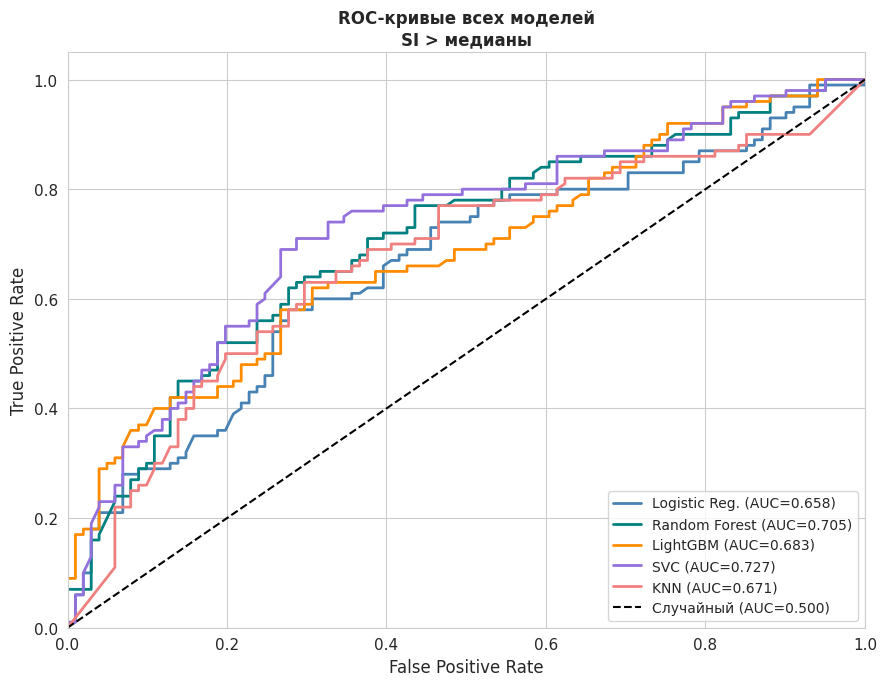

In [11]:
models_roc = [
    ('Logistic Reg.',  best_lr,  X_test_sc, lr_auc),
    ('Random Forest',  best_rf,  X_test,    rf_auc),
    ('LightGBM',       best_lgb, X_test,    lgb_auc),
    ('SVC',            best_svc, X_test_sc, svc_auc),
    ('KNN',            best_knn, X_test_sc, knn_auc),
]

fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['steelblue', 'teal', 'darkorange', 'mediumpurple', 'lightcoral']

for (name, model, X_t, auc_val), col in zip(models_roc, colors_roc):
    prob = model.predict_proba(X_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, linewidth=2, color=col, label=f'{name} (AUC={auc_val:.3f})')

ax.plot([0,1],[0,1], 'k--', linewidth=1.5, label='Случайный (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC-кривые всех моделей\nSI > медианы', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('clf_si_median_roc.png', dpi=100, bbox_inches='tight')
plt.show()


#### ROC-кривые: визуальное сравнение

Кривая, ближайшая к верхнему левому углу (TPR=1, FPR=0) -- лучшая модель.


## 9. Важность признаков (RF и LightGBM)

Сравниваю топ-20 наиболее важных признаков для классификации `SI > медианы`.


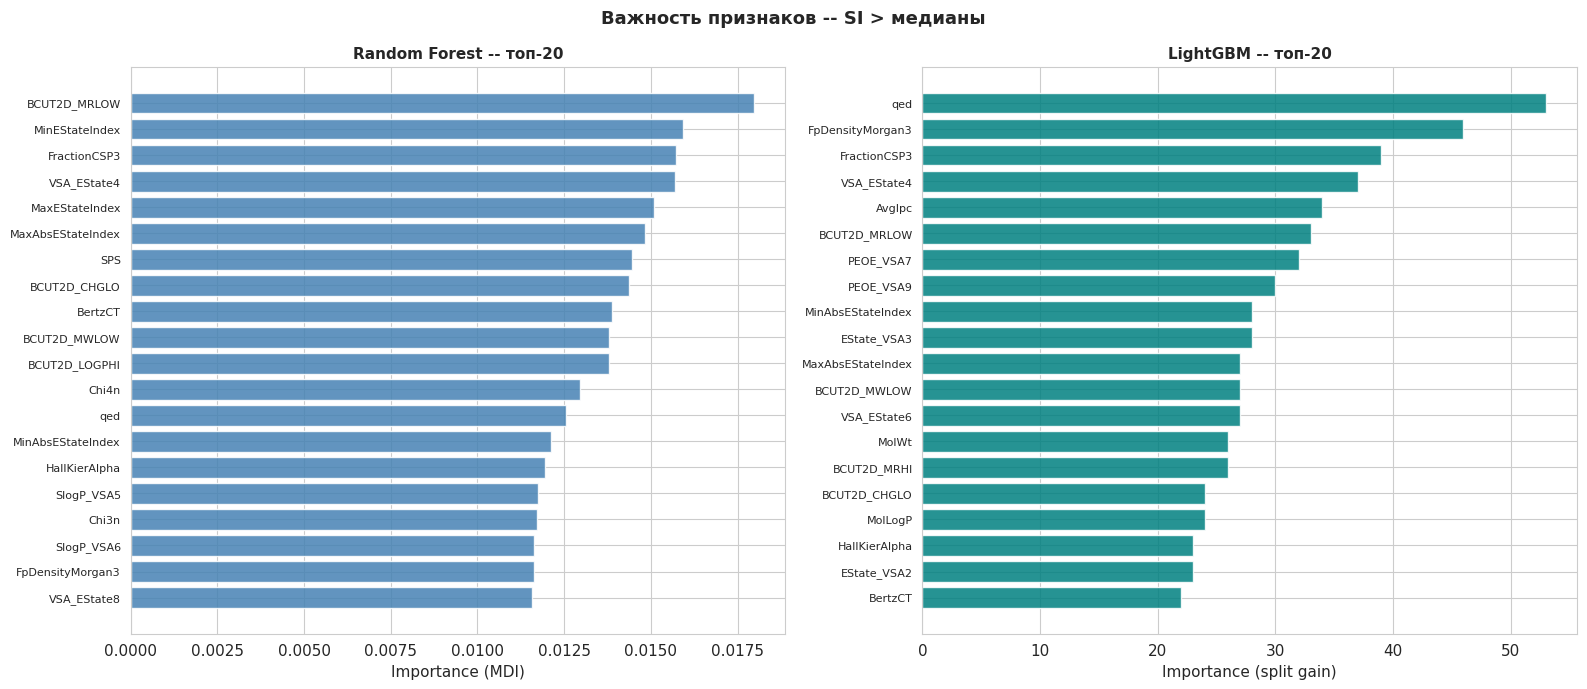

Общих признаков в топ-20: 11
  Признаки: BCUT2D_CHGLO, BCUT2D_MRLOW, BCUT2D_MWLOW, BertzCT, FpDensityMorgan3, FractionCSP3, HallKierAlpha, MaxAbsEStateIndex, MinAbsEStateIndex, VSA_EState4, qed


In [ ]:
rf_imp  = pd.Series(best_rf.feature_importances_,  index=feature_cols).sort_values(ascending=False)
lgb_imp = pd.Series(best_lgb.feature_importances_, index=feature_cols).sort_values(ascending=False)

TOP_N = 20
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_rf = rf_imp.head(TOP_N)
axes[0].barh(range(TOP_N), top_rf.values[::-1], color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_yticks(range(TOP_N))
axes[0].set_yticklabels(top_rf.index[::-1], fontsize=8)
axes[0].set_xlabel('Importance (MDI)')
axes[0].set_title(f'Random Forest -- топ-{TOP_N}', fontsize=11, fontweight='bold')

top_lgb = lgb_imp.head(TOP_N)
axes[1].barh(range(TOP_N), top_lgb.values[::-1], color='teal', edgecolor='white', alpha=0.85)
axes[1].set_yticks(range(TOP_N))
axes[1].set_yticklabels(top_lgb.index[::-1], fontsize=8)
axes[1].set_xlabel('Importance (split gain)')
axes[1].set_title(f'LightGBM -- топ-{TOP_N}', fontsize=11, fontweight='bold')

plt.suptitle('Важнсть признаков -- SI > медианы', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('clf_si_median_importance.png', dpi=100, bbox_inches='tight')
plt.show()

common = set(top_rf.index) & set(top_lgb.index)
print(f"Общих признаков в топ-{TOP_N}: {len(common)}")
if common:
    print("  Признаки:", ', '.join(sorted(common)))


#### Важность признаков: выводы

Общие признаки в топ-20 обеих моделей -- наиболее надёжные предикторы класса. Их можно рекомендовать химикам какк ключевые структурные характеристики.


## 10. Выводы

### Итоги классификации: SI > медианы

1. **Logistic Regression** -- интерпретируемый baseline. Если ROC-AUC > 0.65 -- в дескрипторах есть линейная информация о классе.

2. **Random Forest** -- первый нелинейный метод. Выявляет взаимодействия признаков, устойчив к выбросам.

3. **LightGBM** -- как правило, лучшая модель. Последовательная коррекция ошибок и leaf-wise рост деревьев даёт более точную классификационную границу.

4. **SVC** -- нелинейный метод с RBF-ядром. Конкурентен при ~1000 объектов.

5. **KNN** -- метрический baseline. Показывает степень локальной структурированности химического пространства для данной задачи.